
# Cloning quasars 

Let's look at the redshift distributions of the quasars in the Sloan Digital Sky Survey.

The Sloan Digital Sky Survey or SDSS is a major multi-spectral imaging and spectroscopic redshift survey using a dedicated 2.5-m wide-angle optical telescope at Apache Point Observatory in New Mexico, United States. Operations started in 1998.

In phase 1, SDSS has released photometry data 357 million (!!!) unique sources and 1.6 million spectra. In phase 2, SDSS observed the same patch of the sky many times ("time domain astronomy", and now we're going to have LSST!)


Download the SDSS quasar data

In [13]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']



- Upsample this distribution in two ways, using both rejection sampling and inverse transform.
- Check, at least visually, that the two cloned distribitions are indeed similar to the observed one (for a quantitative check, come back to this point in a few lectures)
- Think about the cosmology of quasars. How do you think they are distributed? Overplot the theorethical distribution to the measured SDSS data. Does that agree with your expectation?

(Hint: It shouldn't. But why?)


In [14]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import poisson
import astropy

### Dataset

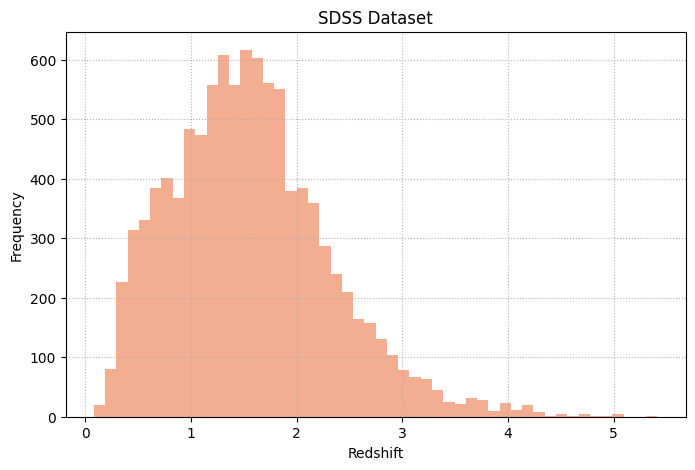

In [83]:
bins = 50

plt.figure(figsize=(8, 5))
counts, edges, figure = plt.hist(z, bins, color='#ef8a62', alpha=0.7)
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.title("SDSS Dataset")
plt.grid(linestyle = ':')
plt.show()

### Rejection Sampling

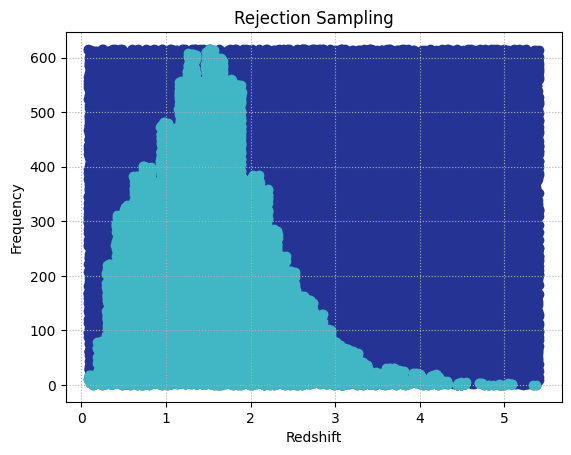

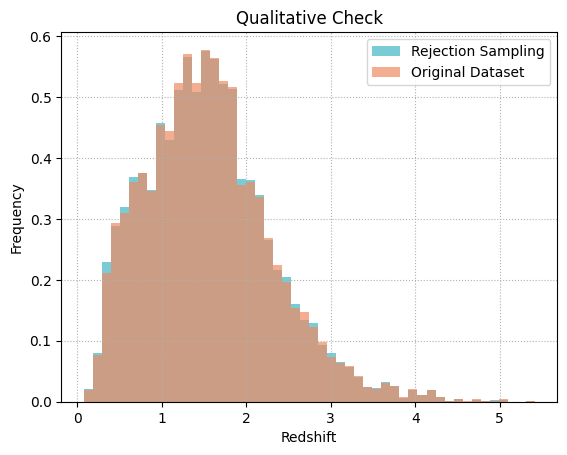

In [88]:
N = int(1000)

ymax = counts.max()

x_scatter, x = [], []
y_scatter, y = [], []

rng = np.random.default_rng()

for i in range(edges.size - 1):
    x_random = rng.uniform(edges[i], edges[i+1], N)
    y_random = rng.uniform(0, ymax, N)
    
    x_scatter.extend(x_random)
    y_scatter.extend(y_random)

    mask = y_random < counts[i]
    x.extend(x_random[mask])
    y.extend(y_random[mask])

x = np.array(x)
y = np.array(y)

plt.scatter(x_scatter, y_scatter, color ='#253494')
plt.scatter(x, y, color='#41b6c4')
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.title("Rejection Sampling")
plt.grid(linestyle = ':')
plt.show()

h1 = plt.hist(x, bins=edges, density=True, color='#41b6c4', alpha=0.7, label='Rejection Sampling')
plt.hist(z, bins, density=True , color='#ef8a62', alpha=0.7, label='Original Dataset')
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.title("Qualitative Check")
plt.grid(linestyle = ':')
plt.legend()
plt.show()

I've just found out that scipy has it already implemented 

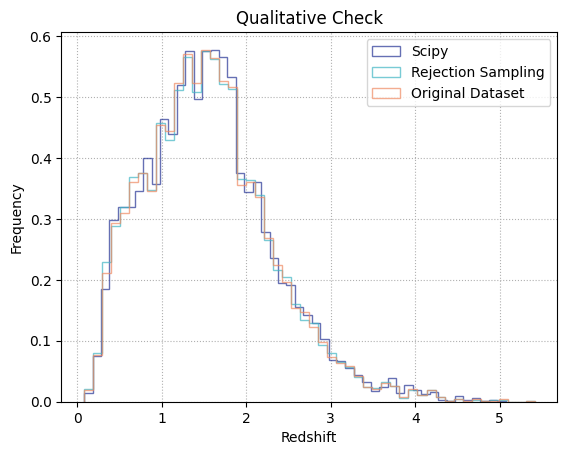

In [92]:
import scipy.stats

disth = scipy.stats.rv_histogram((counts, edges))

plt.hist(disth.rvs(size=10000), bins, density=True, histtype='step', color='#253494', alpha=0.7, label='Scipy')
h1 = plt.hist(x, bins=edges, density=True, histtype='step', color='#41b6c4', alpha=0.7, label='Rejection Sampling')
plt.hist(z, bins, density=True, histtype='step', color='#ef8a62', alpha=0.7, label='Original Dataset')
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.title("Qualitative Check")
plt.grid(linestyle = ':')
plt.legend()
plt.show()


### Inverse Transform Sampling

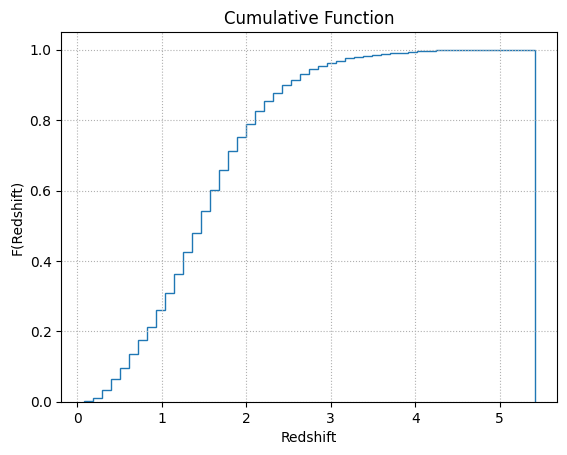

In [17]:
cdf = np.cumsum(counts) / counts.sum()

plt.stairs(cdf, edges)
plt.xlabel("Redshift")
plt.ylabel("F(Redshift)")
plt.title("Cumulative Function")
plt.grid(linestyle = ':')
plt.show()
plt.show()

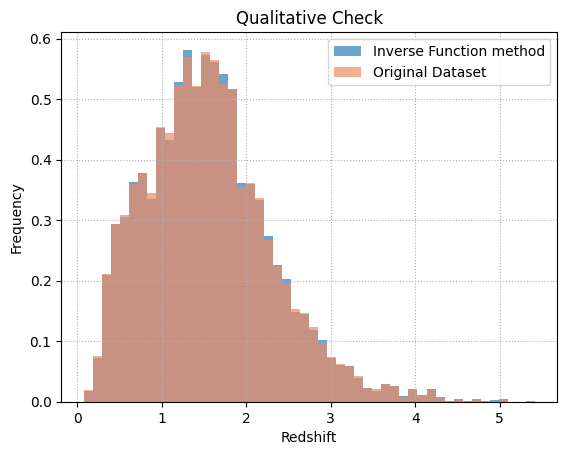

In [90]:
cdf_ext = np.insert(cdf, 0, 0)

n = 100000
x2 = np.zeros(n)

u = rng.uniform(size=n)

for i in range(cdf_ext.size - 1):
    mask = (cdf_ext[i] < u) & (u < cdf_ext[i+1])
    x2[mask] = rng.uniform(edges[i], edges[i+1], x2[mask].size)

h2 = plt.hist(x2, bins=edges, density=True, color='#2c7fb8', alpha=0.7, label='Inverse Function method')
plt.hist(z, bins, density=True , color='#ef8a62', alpha=0.7, label='Original Dataset')
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.title("Qualitative Check")
plt.grid(linestyle = ':')
plt.legend()
plt.show()


### Check with the theoretical distribution

As suggested, let's try to assume that quasars are distributed uniformly in comoving volume in the Universe.

We use the cosmological parameters as measured by the Plack satellite, which is a flat $\Lambda$ CDM model.

In [54]:
astropy.cosmology.Planck18

FlatLambdaCDM(name='Planck18', H0=<Quantity 67.66 km / (Mpc s)>, Om0=0.30966, Tcmb0=<Quantity 2.7255 K>, Neff=3.046, m_nu=<Quantity [0.  , 0.  , 0.06] eV>, Ob0=0.04897)

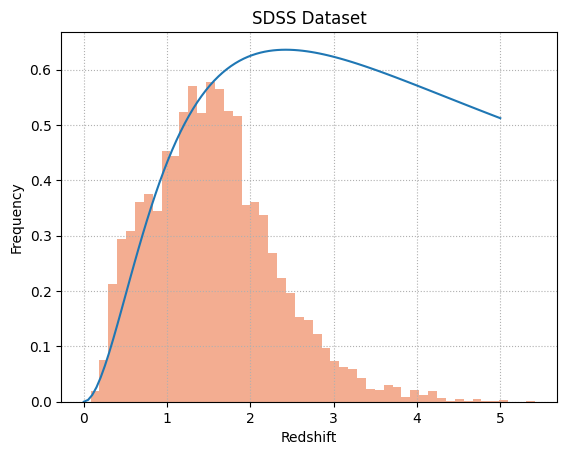

In [94]:
# use comoving volume function
z_vals = np.linspace(0, 5, 100)
pdf_ =  np.pi*astropy.cosmology.Planck18.differential_comoving_volume(z_vals).value
norm_pdf = pdf_ / (2*np.trapezoid(pdf_, dx=0.01)) # arbitrarily normalized

plt.plot(z_vals, norm_pdf)
plt.hist(z, bins, density = True, color='#ef8a62', alpha=0.7)
plt.xlabel("Redshift")
plt.ylabel("Frequency")
plt.title("SDSS Dataset")
plt.grid(linestyle = ':')
plt.show()